# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** Omar Arturo Salcido Moreno

* **matrícula:** A01114221

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++


La rotación de personal ocurre cuando un empleado deja de trabajar en una empresa. Analizarla permite identificar factores como el salario, la edad, la satisfacción laboral o las horas extra que pueden influir en esta decisión. Una alta rotación puede generar mayores costos y afectar el funcionamiento de la empresa por lo que con esta información, la empresa puede tomar mejores decisiones para retener a sus empleados y mejorar sus condiciones del trabajo.




++++++++ Termina la sección de agregar texto. +++++++++++

In [29]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



In [11]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include="all").T

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



In [13]:
# Análisis descriptivo general de todas las variables
display(data.describe(include='all').T)

# Revisamos cuántos valores diferentes tiene cada variable
print("\nCantidad de valores únicos por variable:")
print(data.nunique().sort_values())

# Revisamos las variables candidatas a eliminar
print("\nResumen de variables candidatas a eliminar:")
display(
    data[['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']]
    .describe(include='all')
    .T
)

# Comprobamos si EmployeeNumber funciona como identificador
print("\nNúmero total de registros:", len(data))
print("Valores únicos de EmployeeNumber:", data['EmployeeNumber'].nunique())

# Creamos el nuevo DataFrame eliminando las 4 variables
df = data.drop(columns=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
])

print("\nTamaño del nuevo DataFrame:", df.shape)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0



Cantidad de valores únicos por variable:
EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
A

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
Over18,1470,1,Y,1470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StandardHours,1470.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0



Número total de registros: 1470
Valores únicos de EmployeeNumber: 1470

Tamaño del nuevo DataFrame: (1470, 31)


**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

**

EmployeeCount, Over18 y StandardHours se eliminaron porque tienen el mismo valor para todos los empleados, así que no aportan información útil.
EmployeeNumber se eliminó porque solo sirve para identificar a cada empleado y no cuenta con una caracteristica util para explicar la rotación de personal.


  ++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

**Indpendientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


++++++++ Inicia la sección de agregar texto: ++++++++++++


La edad, el género y el estado civil son datos personales que pueden causar problemas éticos y legales si se usan para tomar decisiones sobre los empleados. Por ejemplo, una empresa no debería despedir, contratar o dar menos oportunidades a una persona solo por ser mayor, mujer, hombre, casada o soltera.
Si el modelo usa estas variables como factores importantes, podría generar decisiones injustas o discriminatorias por lo que aunque estas variables puedan tener relación con la rotación de personal, se deben usar con mucho cuidado y no deberían ser la única razón para tomar decisiones sobre un empleado.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**
Uno sería un modelo de regresión, por ejemplo para predecir el ingreso mensual de un empleado usando características como edad, puesto o años en la empresa.

 Otro enfoque sería un análisis de clustering, para formar grupos de empleados con características parecidas, como nivel de satisfacción, antigüedad o salario. Esto ayudaría a entender mejor los diferentes perfiles de empleados dentro de la empresa.


  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [14]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [17]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


from sklearn.preprocessing import LabelEncoder

# Creamos el codificador
le = LabelEncoder()

# Hacemos copias para conservar ytrain, yval y ytest originales
ytrainT = ytrain.copy()
yvalT = yval.copy()
ytestT = ytest.copy()

# Ajustamos Solo con Train para evitar data leakage
ytrainT['Attrition'] = le.fit_transform(ytrain['Attrition'])

# Usamos el mismo codificador para Validation y Test
yvalT['Attrition'] = le.transform(yval['Attrition'])
ytestT['Attrition'] = le.transform(ytest['Attrition'])

# Revisamos el resultado
print("Clases:", le.classes_)
print("Train:", ytrainT.shape)
print("Validation:", yvalT.shape)
print("Test:", ytestT.shape)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Clases: ['No' 'Yes']
Train: (1029, 1)
Validation: (220, 1)
Test: (221, 1)
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**



++++++++ Inicia la sección de agregar texto: ++++++++++++

b) LabelEncoder se recomienda para transformar la variable objetivo o de salida (y) cuando sus clases están en texto, por ejemplo "Yes" y "No", y convertirlas a números. No se recomienda usarlo directamente para las variables de entrada X.

c) 0(No) significa que el empleado no dejó la empresa, mientras que 1(Yes) significa que el empleado sí dejó la empresa.

d) Como en Train aproximadamente 83.87% de los empleados pertenecen a la clase 0, un modelo baseline que siempre predijera "No" tendría cerca de 83.87% de accuracy. Por lo tanto nuestro modelo debería superar aproximadamente ese valor para mostrar una mejora frente al modelo más básico

e) Sí existe un desbalance de clases, ya que hay muchos más casos "No" que "Yes". Por eso, la accuracy por sí sola puede ser engañosa. Sería mejor revisar también métricas como precision, recall, F1-score y la matriz de confusión, especialmente para evaluar qué tan bien identifica a los empleados que sí dejan la empresa.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


Tamaño del DataFrame: (1470, 31)

Valores faltantes por variable:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtyp

,count,mean,std,min,25%,50%,75%,max
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0



Asimetría de variables numéricas:


,Asimetría
YearsSinceLastPromotion,1.984290
YearsAtCompany,1.764529
MonthlyIncome,1.369817
TotalWorkingYears,1.117172
NumCompaniesWorked,1.026471
DistanceFromHome,0.958118
YearsInCurrentRole,0.917363
YearsWithCurrManager,0.833451
PercentSalaryHike,0.821128
TrainingTimesLastYear,0.553124



Número de valores únicos:


,Valores únicos
Education,5
EnvironmentSatisfaction,4
JobInvolvement,4
JobLevel,5
JobSatisfaction,4
PerformanceRating,2
RelationshipSatisfaction,4
StockOptionLevel,4
WorkLifeBalance,4
Attrition,2


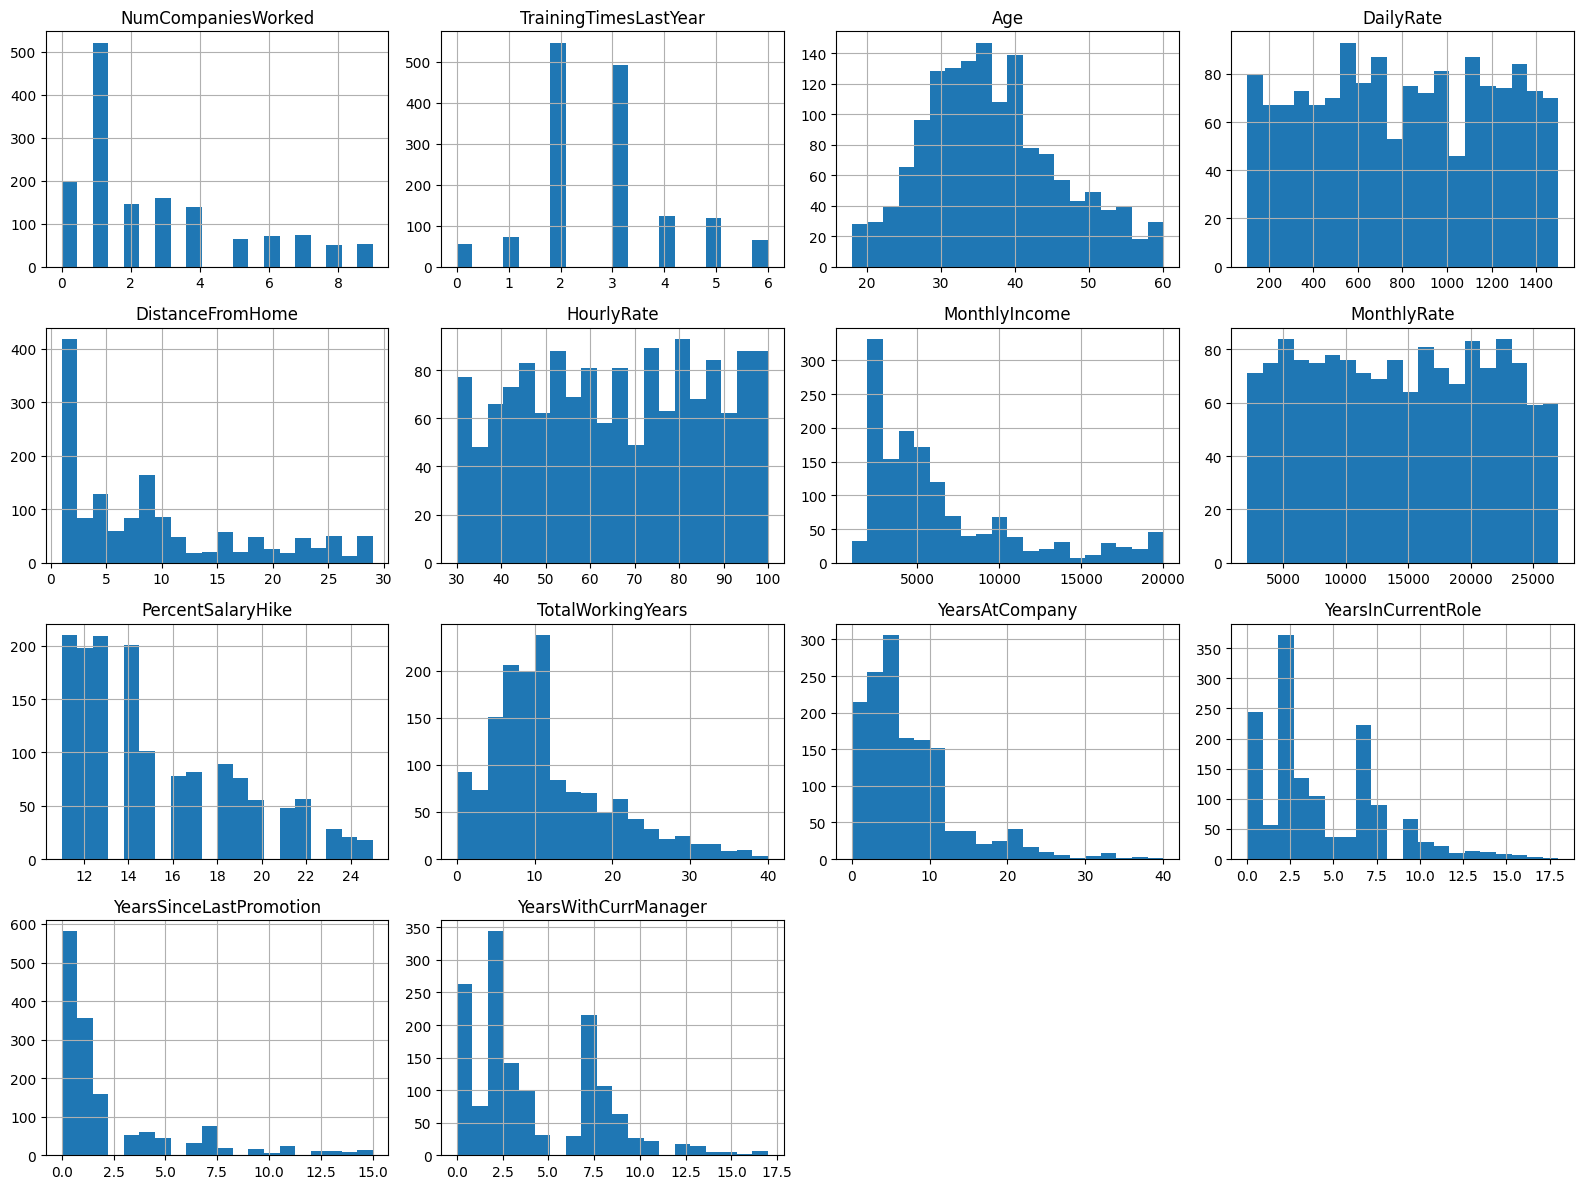


En el análisis se observa que las variables numéricas tienen diferentes escalas
y algunas presentan distribuciones desiguales. También existen variables
categóricas que deberán convertirse a valores numéricos antes de entrenar los modelos.
No se encontraron valores faltantes, por lo que no será necesario hacer
un tratamiento de datos perdidos.



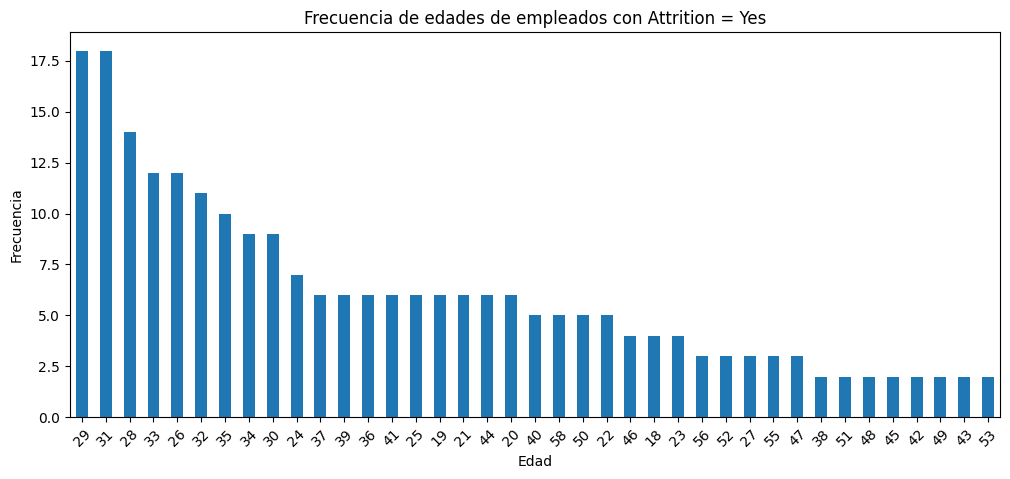

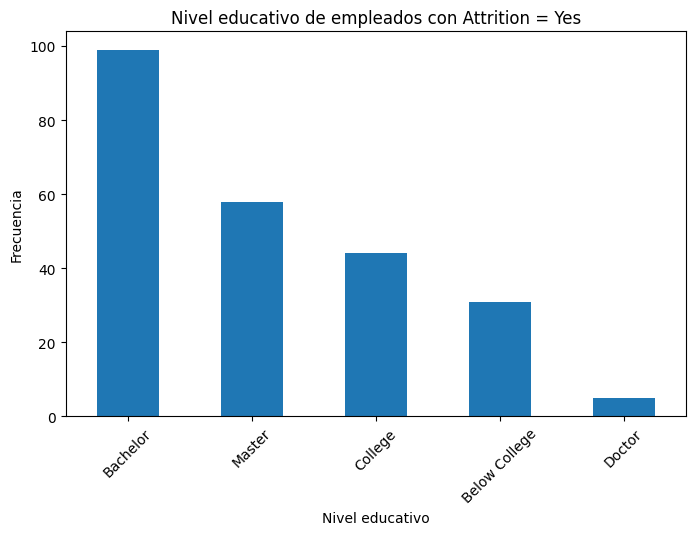

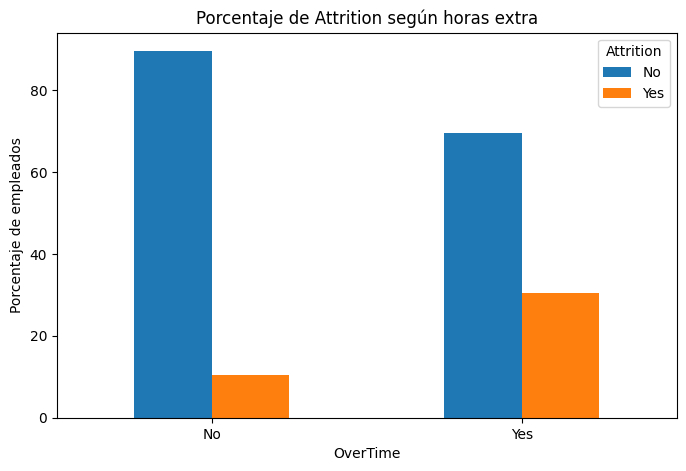

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [24]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

# tipos de variables
numericas = [
    'NumCompaniesWorked', 'TrainingTimesLastYear', 'Age', 'DailyRate',
    'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
    'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

ordinales = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]

binarias = ['Attrition', 'Gender', 'OverTime']

nominales = [
    'BusinessTravel', 'Department', 'EducationField',
    'JobRole', 'MaritalStatus'
]

# Información general
print("Tamaño del DataFrame:", df.shape)
print("\nValores faltantes por variable:")
print(df.isnull().sum())

# Estadísticas de variables numéricas
print("\nResumen de variables numéricas:")
display(df[numericas].describe().T)

# Revisamos asimetría de las variables numéricas
print("\nAsimetría de variables numéricas:")
display(df[numericas].skew().sort_values(ascending=False).to_frame("Asimetría"))

# Cantidad de categorías de variables categóricas
print("\nNúmero de valores únicos:")
display(df[ordinales + binarias + nominales].nunique().to_frame("Valores únicos"))

# Histogramas de variables numéricas
df[numericas].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()



# b) Gráfico age-attrition[yes]



age_yes = (
    df[df['Attrition'] == 'Yes']['Age']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
age_yes.plot(kind='bar')

plt.title('Frecuencia de edades de empleados con Attrition = Yes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# c) Gráfico education-attrition[yes]


education_labels = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

education_yes = (
    df[df['Attrition'] == 'Yes']['Education']
    .map(education_labels)
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
education_yes.plot(kind='bar')

plt.title('Nivel educativo de empleados con Attrition = Yes')
plt.xlabel('Nivel educativo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# d) [gráfico opcional]


overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition.plot(kind='bar', figsize=(8, 5))

plt.title('Porcentaje de Attrition según horas extra')
plt.xlabel('OverTime')
plt.ylabel('Porcentaje de empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.show()

display(overtime_attrition)


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



a)En el análisis se observa que las variables numéricas tienen diferentes escalas
y algunas presentan distribuciones desiguales. También existen variables
categóricas que deberán convertirse a valores numéricos antes de entrenar los modelos.
No se encontraron valores faltantes, por lo que no será necesario hacer
un tratamiento de datos perdidos.


**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Falsos positivos, para IBM sería más costoso clasificar como que no renunciará a un empleado
que en realidad sí va a renunciar, porque la empresa no podría tomar medidas
a tiempo para retenerlo o prepararse para reemplazarlo.




++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [31]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [32]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

numericas_pipeline_nombres = [
    'NumCompaniesWorked', 'TrainingTimesLastYear', 'Age', 'DailyRate',
    'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
    'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]


# ORDINALES:
catOrd_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder())
])

catOrd_pipeline_nombres = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]


# BINARIAS:
catBin_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
])

catBin_pipeline_nombres = [
    'Gender', 'OverTime'
]


# NOMINALES:
catNom_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

catNom_pipeline_nombres = [
    'BusinessTravel', 'Department', 'EducationField',
    'JobRole', 'MaritalStatus'
]


columnasTransformer = ColumnTransformer([
    ('numericas', numericas_pipeline, numericas_pipeline_nombres),
    ('ordinales', catOrd_pipeline, catOrd_pipeline_nombres),
    ('binarias', catBin_pipeline, catBin_pipeline_nombres),
    ('nominales', catNom_pipeline, catNom_pipeline_nombres)
])


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

7a Datos perdidos: usamos SimpleImputer. En numéricas usamos la mediana y en categóricas el valor más frecuente.

7b Numéricas: usamos StandardScaler para poner las variables en una escala similar.

7c Ordinales: usamos OrdinalEncoder porque estas categorías tienen un orden natural

7d Binarias: usamos OneHotEncoder para convertir categorías como Male/Female o Yes/No a valores numéricos.

7e Nominales: usamos OneHotEncoder porque sus categorías no tienen un orden específico.

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [33]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.883 (0.019)
>> LASSO 0.887 (0.017)
>> RIDGE 0.886 (0.016)
>> EN 0.888 (0.017)
>> KNN 0.845 (0.007)


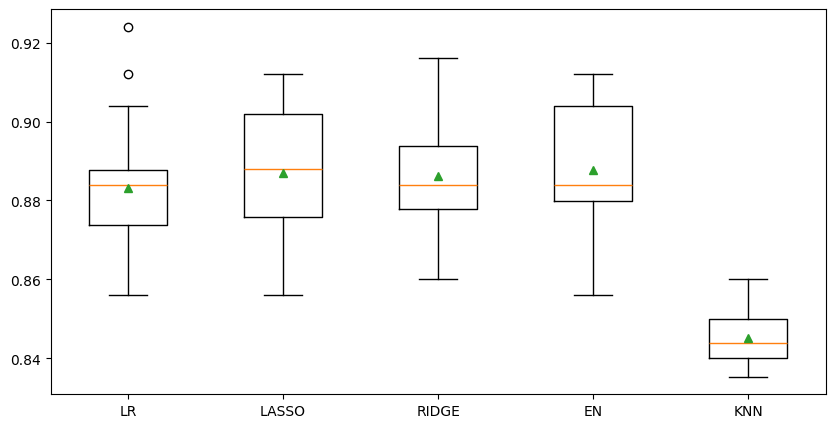

In [34]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
    modelos, nombres = list(), list()

    # LR - Regresión Logística sin regularización:
    modelos.append(LogisticRegression(penalty=None,  # Este valor de "None" no lo debes cambiar. Define al modelo sin regularización.
                                      solver='lbfgs',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('LR')


    # Lasso - Regresión Logística con regularización L1:
    modelos.append(LogisticRegression(penalty='l1',
                                      C=1.0,
                                      solver='liblinear',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('LASSO')


    # Ridge - Regresión Logística con regularización L2:
    modelos.append(LogisticRegression(penalty='l2',
                                      C=1.0,
                                      solver='lbfgs',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('RIDGE')


    # Elastic_Net - - Regresión Logística con regularización L1 y L2:
    modelos.append(LogisticRegression(penalty='elasticnet',
                                      C=1.0,
                                      l1_ratio=0.5,
                                      solver='saga',
                                      max_iter=3000,
                                      random_state=1))
    nombres.append('EN')


    # KNN - K-Vecinos más cercanos:
    modelos.append(KNeighborsClassifier(
                                      n_neighbors=15,
                                      weights='distance',
                                      metric='minkowski',
                                      p=2
                                      ))
    nombres.append('KNN')

    return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
pipe_lasso = Pipeline([
    ('ct', columnasTransformer),
    ('m', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        random_state=1
    ))
])

param_lasso = {
    'm__C': [0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(
    pipe_lasso,
    param_lasso,
    scoring='accuracy',
    cv=cv1
)

grid_lasso.fit(Xtv, np.ravel(ytv))

print("LASSO")
print("Mejores parámetros:", grid_lasso.best_params_)
print("Mejor accuracy:", grid_lasso.best_score_)

LASSO
Mejores parámetros: {'m__C': 1}
Mejor accuracy: 0.8868444444444445


In [37]:
pipe_ridge = Pipeline([
    ('ct', columnasTransformer),
    ('m', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=2000,
        random_state=1
    ))
])

param_ridge = {
    'm__C': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_ridge,
    scoring='accuracy',
    cv=cv1
)

grid_ridge.fit(Xtv, np.ravel(ytv))

print("RIDGE")
print("Mejores parámetros:", grid_ridge.best_params_)
print("Mejor accuracy:", grid_ridge.best_score_)

RIDGE
Mejores parámetros: {'m__C': 1}
Mejor accuracy: 0.8863089692101741


In [38]:
pipe_en = Pipeline([
    ('ct', columnasTransformer),
    ('m', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=3000,
        random_state=1
    ))
])

param_en = {
    'm__C': [0.1, 1, 10],
    'm__l1_ratio': [0.25, 0.5, 0.75]
}

grid_en = GridSearchCV(
    pipe_en,
    param_en,
    scoring='accuracy',
    cv=cv1
)

grid_en.fit(Xtv, np.ravel(ytv))

print("ELASTIC NET")
print("Mejores parámetros:", grid_en.best_params_)
print("Mejor accuracy:", grid_en.best_score_)

ELASTIC NET
Mejores parámetros: {'m__C': 1, 'm__l1_ratio': 0.5}
Mejor accuracy: 0.8876465863453817


In [39]:
pipe_knn = Pipeline([
    ('ct', columnasTransformer),
    ('m', KNeighborsClassifier())
])

param_knn = {
    'm__n_neighbors': [5, 10, 15, 20, 25],
    'm__weights': ['uniform', 'distance'],
    'm__p': [1, 2]
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_knn,
    scoring='accuracy',
    cv=cv1
)

grid_knn.fit(Xtv, np.ravel(ytv))

print("KNN")
print("Mejores parámetros:", grid_knn.best_params_)
print("Mejor accuracy:", grid_knn.best_score_)

KNN
Mejores parámetros: {'m__n_neighbors': 10, 'm__p': 1, 'm__weights': 'distance'}
Mejor accuracy: 0.8524155287817939


In [40]:
def mis_modelos():
    modelos, nombres = list(), list()

    # LR - Regresión Logística sin regularización:
    modelos.append(LogisticRegression(
        penalty=None,
        solver='lbfgs',
        max_iter=2000,
        random_state=1
    ))
    nombres.append('LR')


    # Lasso - Regresión Logística con regularización L1:
    modelos.append(LogisticRegression(
        penalty='l1',
        C=1.0,
        solver='liblinear',
        max_iter=2000,
        random_state=1
    ))
    nombres.append('LASSO')


    # Ridge - Regresión Logística con regularización L2:
    modelos.append(LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=2000,
        random_state=1
    ))
    nombres.append('RIDGE')


    # Elastic_Net - Regresión Logística con regularización L1 y L2:
    modelos.append(LogisticRegression(
        penalty='elasticnet',
        C=1.0,
        l1_ratio=0.5,
        solver='saga',
        max_iter=3000,
        random_state=1
    ))
    nombres.append('EN')


    # KNN - K-Vecinos más cercanos:
    modelos.append(KNeighborsClassifier(
        n_neighbors=10,
        weights='distance',
        metric='minkowski',
        p=1
    ))
    nombres.append('KNN')

    return modelos, nombres

In [41]:
modelos, nombres = mis_modelos()
resultados = list()

>> LR 0.883 (0.019)
>> LASSO 0.887 (0.017)
>> RIDGE 0.886 (0.016)
>> EN 0.888 (0.017)
>> KNN 0.852 (0.008)


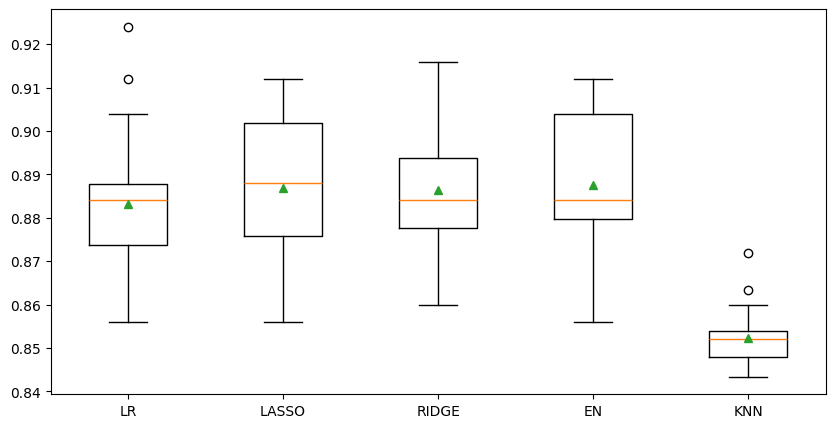

In [42]:
# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

    pipeline = Pipeline(steps=[
        ('ct', columnasTransformer),
        ('m', modelos[i])
    ])

    cv1 = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=7
    )

    scores = cross_val_score(
        pipeline,
        Xtv,
        np.ravel(ytv),
        scoring='accuracy',
        cv=cv1
    )

    resultados.append(scores)

    print('>> %s %.3f (%.3f)' %
          (nombres[i], np.mean(scores), np.std(scores)))

plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.show()

**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Los modelos de regresión logística tuvieron resultados muy parecidos y todos tuvieron un buen desempeño. El mejor resultado fue Elastic Net, con una exactitud promedio de 0.888. Después quedaron LASSO con 0.887, Ridge con 0.886 y LR con 0.883.

El modelo con menor desempeño fue KNN, con una exactitud de 0.852. Aunque se probaron diferentes parámetros para mejorarlo, su resultado siguió siendo menor que el de los demás modelos. Por esta razón, se puede considerar que fue el modelo más limitado en esta comparación.

En conclusión, elegiría Elastic Net como el mejor modelo porque obtuvo la exactitud más alta y mostró un desempeño estable en las diferentes pruebas.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [43]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++




pipeline_en = Pipeline([
    ('ct', columnasTransformer),
    ('m', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=3000,
        random_state=1
    ))
])

param_grid = {
    'm__C': [0.01, 0.1, 0.5, 1, 5, 10],
    'm__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9]
}

resultado_malla = GridSearchCV(
    estimator=pipeline_en,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv1,
    return_train_score=True
)

resultado_malla.fit(Xtv, np.ravel(ytv))




# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.890316 usando los hiperparámetros {'m__C': 0.5, 'm__l1_ratio': 0.25}
Promedios Train mean(std): 89.06% (0.4018%)
Promedios Val mean(std): 87.66% (1.3850%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [44]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


y_pred = resultado_malla.predict(Xtest)



print(classification_report(np.ravel(ytestT), y_pred,
                            target_names=['No','Yes']))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


              precision    recall  f1-score   support

          No       0.88      0.94      0.91       185
         Yes       0.52      0.33      0.41        36

    accuracy                           0.84       221
   macro avg       0.70      0.64      0.66       221
weighted avg       0.82      0.84      0.83       221



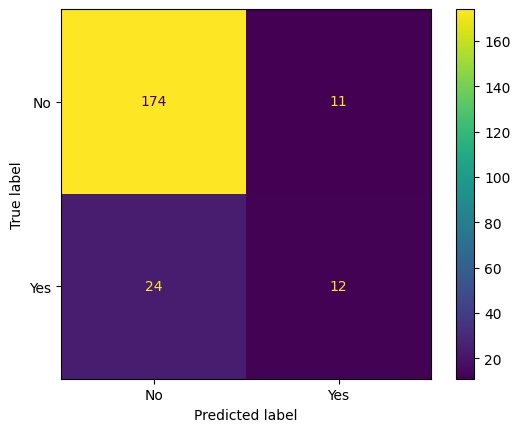

In [45]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


ConfusionMatrixDisplay.from_predictions(
    np.ravel(ytestT),
    y_pred,
    display_labels=['No', 'Yes']
)

plt.show()


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++



* **VP:** El modelo identificó correctamente a 12 empleados que sí renunciaron.

* **VN:** El modelo identificó correctamente a 174 empleados que no renunciaron.

* **FP:** El modelo predijo que 11 empleados renunciarían, aunque en realidad no lo hicieron.

* **FN:** El modelo predijo que 24 empleados no renunciarían, aunque en realidad sí renunciaron.

El modelo identifica bien a los empleados que no renuncian, pero tiene más dificultad para detectar a los que sí renuncian. Esto se observa porque hubo 24 falsos negativos y solo se identificaron correctamente 12 de los empleados que sí dejaron la empresa.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

In [46]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Obtener los nombres de las variables después de las transformaciones
nombres_variables = resultado_malla.best_estimator_['ct'].get_feature_names_out()

# Obtener los coeficientes del mejor modelo
coeficientes = resultado_malla.best_estimator_['m'].coef_[0]

# Crear una tabla con la importancia de cada variable
importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia': abs(coeficientes)
})

# Ordenar de mayor a menor importancia
importancia = importancia.sort_values(by='Importancia', ascending=False)

# Mostrar las 15 variables más importantes
display(importancia.head(15))


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



,Variable,Coeficiente,Importancia
24,binarias__OverTime_Yes,2.004601,2.004601
26,nominales__BusinessTravel_Travel_Frequently,0.895983,0.895983
25,nominales__BusinessTravel_Non-Travel,-0.807426,0.807426
10,numericas__YearsAtCompany,0.725983,0.725983
48,nominales__MaritalStatus_Single,0.712806,0.712806
39,nominales__JobRole_Laboratory Technician,0.669538,0.669538
11,numericas__YearsInCurrentRole,-0.619496,0.619496
16,ordinales__JobInvolvement,-0.602418,0.602418
17,ordinales__JobLevel,-0.466423,0.466423
0,numericas__NumCompaniesWorked,0.461484,0.461484


*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++
Los factores más importantes fueron las horas extra, los viajes de trabajo, los años en la empresa y el estado civil. El factor con mayor influencia fue OverTime = Yes, lo que indica que trabajar horas extra puede estar relacionado con una mayor probabilidad de dejar la empresa. También se observa que viajar con frecuencia por trabajo y algunas características como la antigüedad y el estado civil tienen importancia en la rotación de personal.


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


* a) El modelo debe servir como ayuda para tomar decisiones, pero no para decidir todo por sí solo. También se debe cuidar la privacidad de los empleados y no usar sus datos de forma injusta.


* b) El error más costoso es el falso negativo, porque el modelo dice que un empleado no se va a ir, pero en realidad sí renuncia. Esto coincide con lo que vimos antes.

* c) Explicaría los resultados con palabras fáciles, usando gráficas y ejemplos para que cualquier persona los pueda entender.

* d) El LLM me ayudó más en los ejercicios 6, 7, 8 y 10, porque me ayudó a entender qué hacer, cómo transformar los datos y cómo interpretar los resultados.

* e) En esta actividad aprendí a preparar los datos, probar diferentes modelos y revisar cuál funcionó mejor. También aprendí que es importante entender los errores del modelo y usar los resultados con cuidado.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

**Referencias:**

OpenAI. (2026). ChatGPT (GPT-5.6 Sol) [Modelo de lenguaje grande], utilizado para apoyo en comprensión de conceptos, redacción y análisis de resultados. https://chatgpt.com/

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<